In [173]:
%pip install torch==2.6.0
%pip install torchvision==0.21.0
%pip install numpy
%pip install matplotlib
%pip install tdqm
%pip install numpy==1.24.1
%pip install timm
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.1.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [32 lines of output]
      Traceback (most recent call last):
        File "/Users/thomas/Documents/GitHub/CSE_144_Final_Project/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/thomas/Documents/GitHub/CSE_144_Final_Project/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks

In [174]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange
import os
from tqdm import tqdm
import pathlib
from torchvision.io import decode_image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
from torchvision.transforms import v2
from torch.utils.data import Dataset, Subset
import torchvision.models as models
import timm
from sklearn.model_selection import KFold

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Use hardware acceleration if availaible

In [175]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

mps


### Utility Function: Gets path to model file

In [176]:
# Get path to model, if it exists
def getModelPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'model' in dir_list:
        model_dir_path = os.path.join(path,'model')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(model_dir_path,timestr) + ".pth"

    return model_file_name

### Utility Function: Gets path to weights file

In [177]:
# Get path to weights, if it exists
def getWeightsPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'weights' in dir_list:
        weights_dir_path = os.path.join(path,'weights')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(weights_dir_path,timestr) + ".pth"

    return model_file_name

#### Get path to model_script, if it exists

In [178]:
def getModelScriptPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)

    if 'model_script' in dir_list:
        model_script_dir_path = os.path.join(path,'model_script')
    else:
        raise ValueError("Can't find 'model_script' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dirpath)
    timestr = time.strftime("%Y%m%d%H%M%S")
    model_file_name = os.path.join(model_script_dir_path,timestr) + ".pt"

    return model_file_name

# How to read the data
* Reading the data
* Putting the image stright into ram is not a good idea
* I think maybe I will be using a CVS file that store the classification of the image and the path to the image. 

In [179]:
# https://www.geeksforgeeks.org/python-list-files-in-a-directory/
# https://stackoverflow.com/questions/3430372/how-do-i-get-the-full-path-of-the-current-files-directory
# https://stackoverflow.com/questions/431684/how-do-i-change-the-working-directory-in-python
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'train' in dir_list:
    train_dir_path = os.path.join(os.path.join(path,'train'),'train')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"" + os.path.join(path,'train') + "\"")

# Setting up transform for the image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data
* https://pytorch.org/vision/0.9/transforms.html

In [180]:
# transform = transforms.Compose()
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
])

# Import image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [181]:

dataset = datasets.ImageFolder(train_dir_path,transform=transform)

# Split dataset
* https://discuss.pytorch.org/t/how-to-split-dataset-into-test-and-validation-sets/33987

In [182]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9,0.1])

In [183]:
# all_labels = []
# for _, labels in test_dataset:
#     all_labels.append(labels)

# print(list(set(all_labels)))
# print(len(list(set(all_labels))))
# for item in set(all_labels):
#     print(f"Frequency of {item}: {all_labels.count(item)}")

# Data loaders

In [184]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Image augmentation
* Adversarial attack (Suggested by Johnson)
* Flip
* Inverse
* Rotate
* Zoom

### Resourse on doing augmentation
* https://pytorch.org/vision/main/transforms.html

# Image augmentation function
* https://pytorch.org/vision/main/transforms.html

In [185]:
AUGMENTATIONS: list[v2.Transform] = [
    v2.GaussianNoise(),
    v2.RandomSolarize(threshold=0.1),
    v2.ColorJitter(),
    v2.RandomRotation(degrees=90),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomInvert(),
    v2.RandomCrop(size=(224,224)),
    v2.RandomChannelPermutation(),
    # v2.Grayscale(),
    v2.RandomAutocontrast(),
    v2.RandomEqualize(),
]

MAX_RANDOM_AUGMENTATIONS: int = 15
NUM_AUGMENTATIONS: int = 4

In [186]:
def randomTransform() -> list[v2.Transform]:
    transformations: list[v2.Transform] = []
    numRandomAugmentation: int = random.randint(1, MAX_RANDOM_AUGMENTATIONS)
    
    for _ in range(numRandomAugmentation):
        transformations.append(random.choice(AUGMENTATIONS))
        
    transformations.append(v2.Resize((224,244)))
    return v2.Compose(transformations)

randomTransform()

Compose(
      RandomSolarize(p=0.5, threshold=0.1)
      GaussianNoise(mean=0.0, sigma=0.1, clip=True)
      RandomHorizontalFlip(p=0.5)
      RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      ColorJitter()
      RandomSolarize(p=0.5, threshold=0.1)
      RandomEqualize(p=0.5)
      RandomChannelPermutation()
      RandomSolarize(p=0.5, threshold=0.1)
      RandomAutocontrast(p=0.5)
      Resize(size=[224, 244], interpolation=InterpolationMode.BILINEAR, antialias=True)
)

In [187]:
# Horizontally flip each image at the given probability
def augment_images(images: torch.Tensor, labels: torch.Tensor) -> tuple:
    augmented_images = []
    augmented_labels = []
    
    # Create multiple augmentations for each image
    for i, image in enumerate(images):
        # Create 4 augmentations for each image
        rand: int = random.randint(0, NUM_AUGMENTATIONS-1)
        for j in range(NUM_AUGMENTATIONS):
            # keep original image untouched
            if(j == rand):
                augmented = image
                augmented_images.append(augmented)
                augmented_labels.append(labels[i])
                continue
            # Create a new transform composition for each augmentation
            transforms2 = randomTransform()
            
            # Apply the transform directly
            augmented = transforms2(image)
            augmented_images.append(augmented)
            augmented_labels.append(labels[i])
    
    permutation = np.random.permutation(len(augmented_images))
    augmented_images = np.array(augmented_images)[permutation]
    augmented_labels = np.array(augmented_labels)[permutation]

    # Convert lists to tensors
    augmented_images_tensor = torch.stack([torch.tensor(img) for img in augmented_images])
    augmented_labels_tensor = torch.tensor(augmented_labels)

    
    return augmented_images_tensor, augmented_labels_tensor

# # Test the function
# images, labels = next(iter(test_loader))
# augmented_batch, augmented_labels = augment_images(images[:5], labels[:5])  # Get 5 images and their augmentations
# print(f"Original images shape: {images[:5].shape}")
# print(f"Augmented images shape: {augmented_batch.shape}")
# print(f"Augmented labels shape: {augmented_labels.shape}")

In [188]:
# plt.figure(figsize=(20, 20))

# # Get 5 images and their augmentations
# images, labels = next(iter(test_loader))



# # Use the revised function for visualization
# augmented_batch, augmented_labels = augment_images(images, labels)  

# # Plot original and augmented images
# for i in range(5):
#     # Original image
#     plt.subplot(5, 5, i*5 + 1)
#     plt.imshow(augmented_batch[i*NUM_AUGMENTATIONS].permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC
#     plt.title(f"Original {i+1}")
#     plt.axis("off")

#     # Augmented images
#     for j in range(NUM_AUGMENTATIONS-1):
#         plt.subplot(5, 5, i*5 + j + 2)
#         plt.imshow(augmented_batch[i*NUM_AUGMENTATIONS + j + 1].permute(1, 2, 0).cpu())
#         plt.title(f"Augment {j+1}")
#         plt.axis("off")

# plt.tight_layout()
# plt.show()


In [189]:
print(timm.list_models("efficientnet*"))

['efficientnet_b0', 'efficientnet_b0_g8_gn', 'efficientnet_b0_g16_evos', 'efficientnet_b0_gn', 'efficientnet_b1', 'efficientnet_b1_pruned', 'efficientnet_b2', 'efficientnet_b2_pruned', 'efficientnet_b3', 'efficientnet_b3_g8_gn', 'efficientnet_b3_gn', 'efficientnet_b3_pruned', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_b8', 'efficientnet_blur_b0', 'efficientnet_cc_b0_4e', 'efficientnet_cc_b0_8e', 'efficientnet_cc_b1_8e', 'efficientnet_el', 'efficientnet_el_pruned', 'efficientnet_em', 'efficientnet_es', 'efficientnet_es_pruned', 'efficientnet_h_b5', 'efficientnet_l2', 'efficientnet_lite0', 'efficientnet_lite1', 'efficientnet_lite2', 'efficientnet_lite3', 'efficientnet_lite4', 'efficientnet_x_b3', 'efficientnet_x_b5', 'efficientnetv2_l', 'efficientnetv2_m', 'efficientnetv2_rw_m', 'efficientnetv2_rw_s', 'efficientnetv2_rw_t', 'efficientnetv2_s', 'efficientnetv2_xl']


# Learning transfer learning from exercise
* https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs?usp=sharing

In [190]:
# Define custom classification head
class RegNetHead(nn.Module):
    def __init__(self, in_features=3712, num_classes=100):  # Adjust `in_features` to match RegNet output
        super(RegNetHead, self).__init__()
         # self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            # nn.Linear(in_features, 1000),
            # nn.ReLU(),
            # nn.Linear(in_features, 1000),
            # nn.Linear(1000, num_classes),
            # nn.Dropout(p=0.5,inplace=True),
            # nn.Linear(in_features, num_classes),
            nn.Linear(in_features, 1000),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(1000, num_classes),
            # nn.Softmax()  # Ensure softmax is applied along the correct dimension
        )

    def forward(self, x):
        # x = self.avgpool(x)
        return self.classifier(x)

# Load pretrained RegNet model
base_model = models.regnet_y_32gf(weights=models.RegNet_Y_32GF_Weights.IMAGENET1K_V2).to(device)
# base_model = models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.DEFAULT).to(device)
# base_model = timm.create_model("efficientnet_b7", pretrained=True, num_classes=100)

# Remove the original classifier (fc layer) and add our custom head
in_features = base_model.fc.in_features  # Get input features of last linear layer
base_model.fc = RegNetHead(in_features=in_features, num_classes=100).to(device)  # Replace with custom head

# Verify Model Architecture
print(base_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(232, 232, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1):

In [191]:
# Freeze all layers first
for param in base_model.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block (block4 in RegNet)
# for param in base_model.trunk_output[3].parameters():  # Block 4 in trunk_output
#     param.requires_grad = True

# Unfreeze the classification head (fc layer)
for param in base_model.fc.parameters():
    param.requires_grad = True

for name, param in base_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")

# Verify trainable parameters
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Trainable Parameters: {trainable_params}/{total_params}")

Trainable: fc.classifier.0.weight
Trainable: fc.classifier.0.bias
Trainable: fc.classifier.3.weight
Trainable: fc.classifier.3.bias
Trainable Parameters: 3813100/145146870


# Setting up the nn
* This code is from https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs#scrollTo=3kTYygi258Yv
* https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau

In [192]:
SHOULD_LOAD_MODEL_FROM_DISK = False

# Initialize the network and optimizer
# base_model = models.vgg16(pretrained=True).to(device=device)
net = RegNetHead().to(device=device)

if SHOULD_LOAD_MODEL_FROM_DISK:
    net.load_state_dict(torch.load(getModelPath(), weights_only=True))
    net.eval()

# optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Accuracy calculation
* https://pytorch.org/docs/stable/generated/torch.nn.functional.one_hot.html

In [193]:
# Function to calculate accuracy
def accuracy(loader, base_model):
    base_model.eval()  # Put model in eval model so no weight updates
    correct = 0
    total = 0
    loss = 0
    total_batches = 0
    with torch.no_grad():
        for data in loader:
            image, label = data
            image, label = image.to(device=device), label.to(device=device)
            with torch.no_grad():
              output = base_model(image)

            _, predicted = torch.max(output.data, 1)

            loss += criterion(output, label)
            loss.cpu()
            
            total += label.size(0)
            correct += (predicted == label).sum().item()
            total_batches += 1
    return loss / total_batches, correct / total

def MyhillNerode(*args):
    return accuracy(*args)

# L1/L2 Regularization
* https://www.geeksforgeeks.org/l1l2-regularization-in-pytorch/

In [194]:
REGULARIZATION_LAMDA = 0.01
REGULARIZATION_MODE = 0

In [195]:
def regularization(model,mode):
    if(mode == 1):
        return sum(p.abs().sum() for p in model.parameters())
    elif(mode == 2):
        return sum(p.pow(2).sum() for p in model.parameters())
    else:
        return 0

# Training

In [196]:
# indice = random.sample(train_dataset.indices,batch_size)
# indice = torch.tensor(indice)
# try1 = dataset[indice]

In [ ]:
import torch.utils
import torch.utils.data
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset

class BaileyNetwork:
    def __init__(self, optimizer, base_model, scheduler):
        self.optimizer = optimizer
        self.base_model = base_model
        self.scheduler = scheduler

    def train(self, dataset: Dataset, epochs=10, num_batches=10, k_folds = 5):

        self.base_model.train()

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=SEED)  # Ensure randomness

        losses_train, losses_val = [], []
        accs_val = []

        batch_size = int(len(dataset) / num_batches)

        # train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8,0.2])

        for epoch_id in tqdm(range(epochs)):

            epoch_loss = 0
            val_loss = 0

            train_acc = 0
            val_acc = 0

            fold_rand = 0


            for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(dataset)))):

                train_correct = 0

                train_loss = 0

                train_total = 0

                train_batches = 0

                if (fold_rand != fold):
                    continue

                # Create train and validation subsets for this fold
                train_subset = Subset(dataset, train_idx)
                val_subset = Subset(dataset, val_idx)

                train_loader = DataLoader(train_subset, batch_size=100, shuffle=False)

                # Lists to store augmented data
                augmented_images_list = []
                augmented_labels_list = []

                # Apply augmentation to each batch
                for x_batch, y_batch in train_loader:
                    x_batch, y_batch = augment_images(x_batch, y_batch)  
                    augmented_images_list.append(x_batch)
                    augmented_labels_list.append(y_batch)

                # Concatenate all augmented batches
                augmented_images_tensor = torch.cat(augmented_images_list, dim=0)
                augmented_labels_tensor = torch.cat(augmented_labels_list, dim=0)

                # Create a new dataset from augmented data
                augmented_train_dataset = TensorDataset(augmented_images_tensor, augmented_labels_tensor)

                # Create a DataLoader from augmented data
                augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=False)

                # train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

                # Get the batch data 
                for x_batch, y_batch in augmented_train_loader:

                    train_batches += 1

                    # Apply augmentation and normalization 

                    # x_batch, y_batch = augment_images(x_batch, y_batch)    

                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                    # x_batch = normalize_images(x_batch)

                    # ===========================
                    # Setting up to run the model
                    # ===========================

                    self.optimizer.zero_grad()      # Reset grad to zero

                    outputs = self.base_model(x_batch)                 # Running our model
                    
                    loss = criterion(outputs, y_batch)          # Calculating the loss

                    # loss += REGULARIZATION_LAMDA * regularization(self.base_model,REGULARIZATION_MODE) 

                    loss.backward()                                  # Back propagation 

                    # Update parameters using the optimizer 
                    self.optimizer.step()                                 # Update parameters

                    _, predicted = torch.max(outputs.data, 1)
                    train_correct += (predicted == y_batch).sum().item()
                    train_total += len(x_batch)

                    # per fold loss calcualtion
                    train_loss += loss.item()
                
                loss_val, acc_val = MyhillNerode(val_loader, self.base_model)

                val_loss += loss_val
                val_acc += acc_val

                epoch_loss += train_loss / train_batches
                train_acc += train_correct / train_total

            # Print epoch statistics
            loss_train = epoch_loss / (1)

            loss_val = val_loss / (1)
            self.scheduler.step(loss_val)

            acc_val = val_acc / (1)
            acc_train = train_acc / (1)

            losses_train.append(loss_train)
            losses_val.append(loss_val)
            accs_val.append(acc_val)

            if(epoch_id%10 == 0):
                torch_script_model = torch.jit.script(base_model)
                torch.jit.save(torch_script_model,str(epoch_id)+'__'+getModelScriptPath())

            tqdm.write(f"Epoch {epoch_id + 1}/{epochs}, Training Loss: {loss:.4f}, Training ACC: {acc_train:.4f}, Validation Loss: {loss_val:.4f}, Validation ACC: {acc_val:.4f}")

        return losses_train, losses_val, accs_val

# Training

#### Hyperparameters

In [200]:
EPOCHS: int = 30
BATCHES: int = 10
LEARNING_RATE: float = 0.02

In [201]:
# optimizer = torch.optim.SGD(base_model.parameters(), lr=LEARNING_RATE, momentum=0.9)
optimizer = torch.optim.AdamW(base_model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

trainer = BaileyNetwork(optimizer=optimizer, base_model=base_model,scheduler=scheduler)

In [202]:
losses_train, losses_val, accs_val = trainer.train(dataset,epochs=EPOCHS)

  3%|▎         | 1/30 [01:13<35:44, 73.95s/it]

Epoch 1/30, Training Loss: 4.8255, Training ACC: 0.0078, Validation Loss: 4.5798, Validation ACC: 0.0400


  7%|▋         | 2/30 [02:22<32:57, 70.61s/it]

Epoch 2/30, Training Loss: 4.6612, Training ACC: 0.0506, Validation Loss: 4.5077, Validation ACC: 0.0900


 10%|█         | 3/30 [03:30<31:15, 69.45s/it]

...

Epoch 28/30, Training Loss: 1.3766, Training ACC: 0.6731, Validation Loss: 1.9080, Validation ACC: 0.4500


 97%|█████████▋| 29/30 [34:17<01:13, 73.45s/it]

Epoch 29/30, Training Loss: 1.3334, Training ACC: 0.6987, Validation Loss: 1.8859, Validation ACC: 0.4450


100%|██████████| 30/30 [35:28<00:00, 70.96s/it]

Epoch 30/30, Training Loss: 1.4855, Training ACC: 0.6987, Validation Loss: 1.8774, Validation ACC: 0.4350


ValueError: x and y must have same first dimension, but have shapes (50,) and (10,)

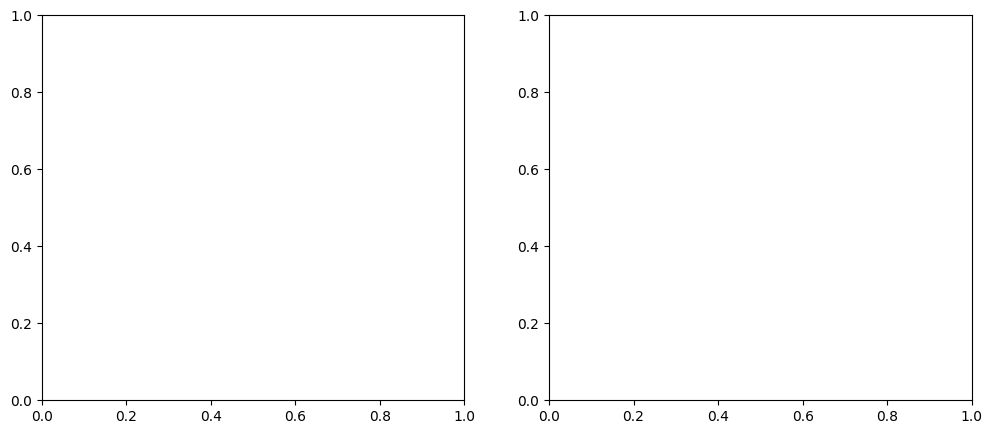

In [168]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

axes[0].plot(np.arange(EPOCHS), losses_train, label="Train loss")
cpu_losses_val = [tensor.cpu() for tensor in losses_val]
axes[0].plot(np.arange(EPOCHS), cpu_losses_val, label="Val loss")
axes[0].set_title("Train + Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(np.arange(EPOCHS), accs_val, label="Val ACC")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ACC")
axes[1].legend()

plt.tight_layout()
plt.show()

# Stopping point

# Save it

#### Save the weights

In [203]:
torch.save(base_model.state_dict(), getWeightsPath())

#### Save the model

In [204]:
torch.save(base_model, getModelPath())

#### TorchScript save model
* https://pytorch.org/docs/stable/generated/torch.jit.script.html

In [205]:
torch_script_model = torch.jit.script(base_model)
torch.jit.save(torch_script_model,getModelScriptPath())